Regime classification is of great use in financial applications, if we kno how the market behaves we can adjust our strategy accordingly. Of course this means we must have an online/streaming variant of whatever classification algorithm we are using, in order to detect in real time whether a new regime is likely entered or what regime we most likely are in the last couple of weeks. 

This small project is inspired by the two papers "Clustering Market Regimes using the Wasserstein Distance" (https://arxiv.org/abs/2110.11848) and "Automated regime classification in multidimensional time series data using sliced Wasserstein k-means clustering" (https://arxiv.org/abs/2310.01285).

I plan to examine this topic in a set of two notebooks, the first one (this one) aims to mention some of the (compacted, not as detailed math this time unfortunately) theory behind the Wasserstein distance and how it is used to form the Wasserstein k-means clustering algorithm used for a posteriori regime classification. I will also compare with a more classical algorithm which looks at moments of recent distributions to cluster regimes together.

In the other notebook I will adapt the Wasserstein k-means algorithm to work in real time and compare its performance to one or two other alternatives that use the Wasserstein distance with other clustering algorithms. Maybe I will also compare with a "classical" algorithm (HMM?). 

Lets start by defining the problem. Say we have two regimes driven by GBMs, one "Bullish" with $\mu = 0.02, \sigma = 0.2$ and one "Bearish" with $\mu = -0.02, \sigma = 0.3$. We build a price time series (starting at 1) and log returns where the two regimes are randomly switched between.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance as scipy_w1

np.random.seed(14)

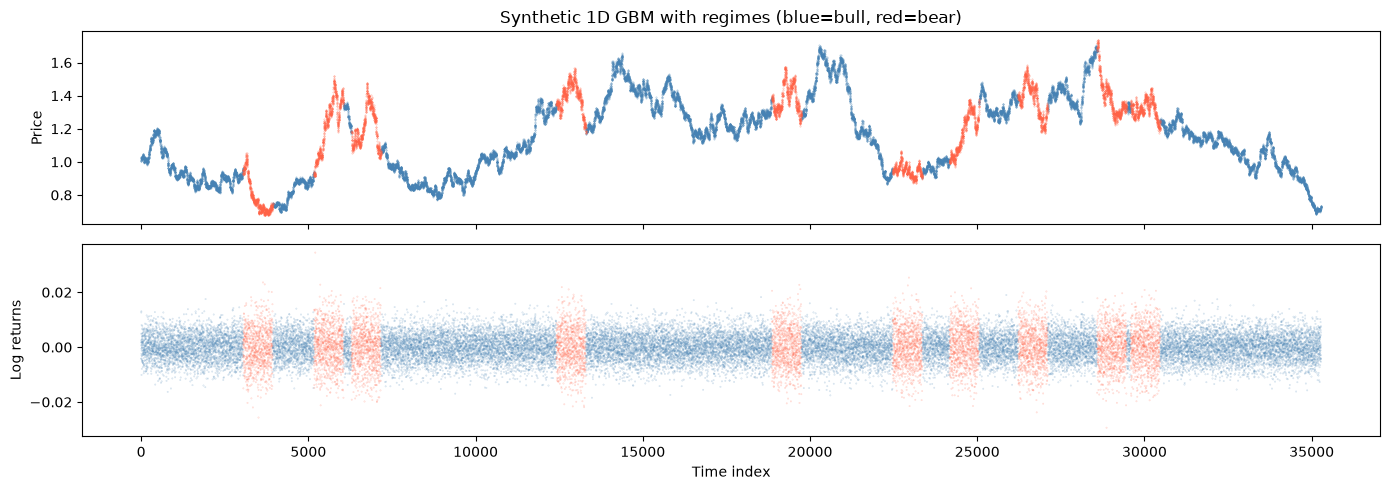

N=35280, Bull fraction: 75.00%


In [2]:
def generate_gbm_1d(n_years=20, obs_per_day=7, days_per_year=252, theta_bull=(0.02, 0.2), theta_bear=(-0.02, 0.3), n_bear_periods=10, bear_length_years=0.5, seed=14):
    """Generate 1D GBM with bullish/bearish regimes."""
    rng = np.random.default_rng(seed)
    N = n_years * days_per_year * obs_per_day
    dt = 1.0 / (days_per_year * obs_per_day)
    bear_len = int(bear_length_years * days_per_year * obs_per_day)
    
    # Place bearish periods randomly (non-overlapping)
    labels = np.zeros(N, dtype=int)  # 0=bull, 1=bear
    starts = []
    for _ in range(n_bear_periods):
        for _attempt in range(1000):
            s = rng.integers(0, N - bear_len)
            if all(abs(s - prev) >= bear_len for prev in starts):
                starts.append(s)
                break
        labels[s:s+bear_len] = 1
    
    # Generate returns
    mu_bull, sig_bull = theta_bull
    mu_bear, sig_bear = theta_bear
    returns = np.where(
        labels == 0,
        rng.normal((mu_bull - sig_bull**2/2)*dt, sig_bull*np.sqrt(dt), N),
        rng.normal((mu_bear - sig_bear**2/2)*dt, sig_bear*np.sqrt(dt), N),
    )
    prices = np.exp(np.cumsum(returns))
    return prices, returns, labels


prices_1d, returns_1d, true_labels_1d = generate_gbm_1d()

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
t = np.arange(len(prices_1d))
for regime in [0, 1]:
    mask = true_labels_1d == regime
    axes[0].scatter(t[mask], prices_1d[mask], s=0.1, 
                    c='steelblue' if regime==0 else 'tomato', alpha=0.5)
axes[0].set_ylabel('Price'); axes[0].set_title('Synthetic 1D GBM with regimes (blue=bull, red=bear)')
axes[1].scatter(t, returns_1d, s=0.1, c=np.where(true_labels_1d==0, 'steelblue', 'tomato'), alpha=0.3)
axes[1].set_ylabel('Log returns'); axes[1].set_xlabel('Time index')
plt.tight_layout(); plt.show()
print(f"N={len(returns_1d)}, Bull fraction: {(true_labels_1d==0).mean():.2%}")

The goal is then to classify these bear and bull regions correctly. As mentioned, in this notebook I look at methods of doing this given the entire time series data (unlabeled of course), not in a non-lookahead online/streaming manner.

Lets first give a quick walkthrough of the k-means clustering algorithm.
Given data $\{\mathbf{x}_1, \dots, \mathbf{x}_N\} \subset \mathbb{R}^d$ and a desired number of clusters $k$:

1. **Initialise** centroids $\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_k$ (e.g. randomly).
2. **Assign** each point to its nearest centroid: $\; c(i) = \arg\min_j \|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2$.
3. **Update** each centroid as the mean of its assigned points: $\; \boldsymbol{\mu}_j = \frac{1}{|C_j|}\sum_{i \in C_j} \mathbf{x}_i$.
4. **Repeat** steps 2–3 until assignments no longer change (or a max-iteration limit is reached).

The algorithm monotonically decreases the objective $J = \sum_{j=1}^{k}\sum_{i \in C_j}\|\mathbf{x}_i - \boldsymbol{\mu}_j\|^2$ and converges to a local minimum. It is sensitive to initialisation, hence multiple restarts are common.


Lets now introduce two baseline models that we will compare Wasserstein k-means with: Rolling Moments k-means and Hidden Markov Model (HMM).

**Rolling Moments k-means** computes rolling moments (mean and variance) of the log-return series over a fixed window $w$ and cluster the resulting feature vectors with k-means. I don't know if there is a "standard" way of doing this but in my implementation the step by step looks like:

1. For each $t \ge w$, form the window $\mathbf{r}_t = (r_{t-w+1}, \dots, r_t)$ and compute:
$$\hat{\mu}_t = \frac{1}{w}\sum_{i=t-w+1}^{t} r_i, \qquad \hat{\sigma}_t = \sqrt{\frac{1}{w-1}\sum_{i=t-w+1}^{t}(r_i - \hat{\mu}_t)^2}$$

2. Construct $\mathbf{x}_t = (\hat{\mu}_t,\; \hat{\sigma}_t) \in \mathbb{R}^2$.

3. Apply k-means to the set $\{\mathbf{x}_t\}$, i.e. minimise the within-cluster sum of squares:
$$\min_{C_1, C_2} \sum_{j=1}^{k} \sum_{\mathbf{x}_t \in C_j} \|\mathbf{x}_t - \boldsymbol{\mu}_j\|^2 \text{, where } \boldsymbol{\mu}_j \text{ is the centroid of cluster } C_j.$$
    

4. Assign each $t$ a regime label from its cluster membership. Since k-means labels are arbitrary, we pick the label permutation that maximises accuracy.



**Hidden Markov Model (HMM)** models the returns as "being driven" from a latent Markov chain with $k$ hidden states, each associated with a Gaussian distribution.

**Mathematical formulation:**

- Hidden state sequence: $\{s_t\}_{t=1}^T$, with $s_t \in \{1, \ldots, k\}$.
- Transition matrix: $A_{ij} = P(s_{t+1}=j \mid s_t = i)$.
- Initial distribution: $\pi_i = P(s_1 = i)$.
- Emission model: $r_t \mid s_t = k \;\sim\; \mathcal{N}(\mu_k,\, \sigma_k^2)$.

**Steps:**

1. **Parameter estimation.** Maximise the incomplete-data (because we observe $r$ not $s$ it is incomplete-data) log-likelihood: $$\log P(\mathbf{r} \mid \theta) = \log \sum_{\mathbf{s}} P(\mathbf{r}, \mathbf{s} \mid \theta)$$ via the EM algorithm (which I wont cover).


2. **State decoding (Viterbi).** Find the most likely state path: $$\mathbf{s}^* = \arg\max_{\mathbf{s}} P(\mathbf{s} \mid \mathbf{r}, \theta)$$ (apparently) computed via dynamic programming in $\mathcal O(TK^2)$ time.

3. Assign regime labels from $\mathbf{s}^*$ and, as before, resolve label permutation against the ground truth.

We use 2 clusters for rolling moments k-means and 2 states for HMM.

In [3]:
from sklearn.cluster import KMeans
from hmmlearn.hmm import GaussianHMM

# --- 1. K-Means on rolling moments ---
window = 252  # ~1 month of intraday observations (252 = days_per_year * 1 day)
roll_mean = np.convolve(returns_1d, np.ones(window)/window, mode='valid')
roll_std = np.array([returns_1d[i:i+window].std() for i in range(len(returns_1d)-window+1)])

features = np.column_stack([roll_mean, roll_std])
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10).fit(features)
km_labels = kmeans.labels_

# Align with true labels (rolling window loses first window-1 points)
true_aligned = true_labels_1d[window-1:]

# K-Means labels are arbitrary (0/1 may be flipped) — pick best alignment
acc_km = max((km_labels == true_aligned).mean(), (km_labels != true_aligned).mean())
print(f"K-Means on moments accuracy: {acc_km:.2%}")

# --- 2. Hidden Markov Model ---
hmm = GaussianHMM(n_components=2, covariance_type='full', n_iter=200, random_state=42)
hmm.fit(returns_1d.reshape(-1, 1))
hmm_labels = hmm.predict(returns_1d.reshape(-1, 1))

acc_hmm = max((hmm_labels == true_labels_1d).mean(), (hmm_labels != true_labels_1d).mean())
print(f"HMM (2-state Gaussian) accuracy: {acc_hmm:.2%}")
print(f"\nHMM learned means: {hmm.means_.flatten()}")
print(f"HMM learned stds:  {np.sqrt(hmm.covars_.flatten())}")

K-Means on moments accuracy: 92.75%


Model is not converging.  Current: 135028.77035674723 is not greater than 135028.77516099575. Delta is -0.004804248514119536


HMM (2-state Gaussian) accuracy: 99.56%

HMM learned means: [-1.88211526e-06 -3.01332960e-05]
HMM learned stds:  [0.00477544 0.00722827]


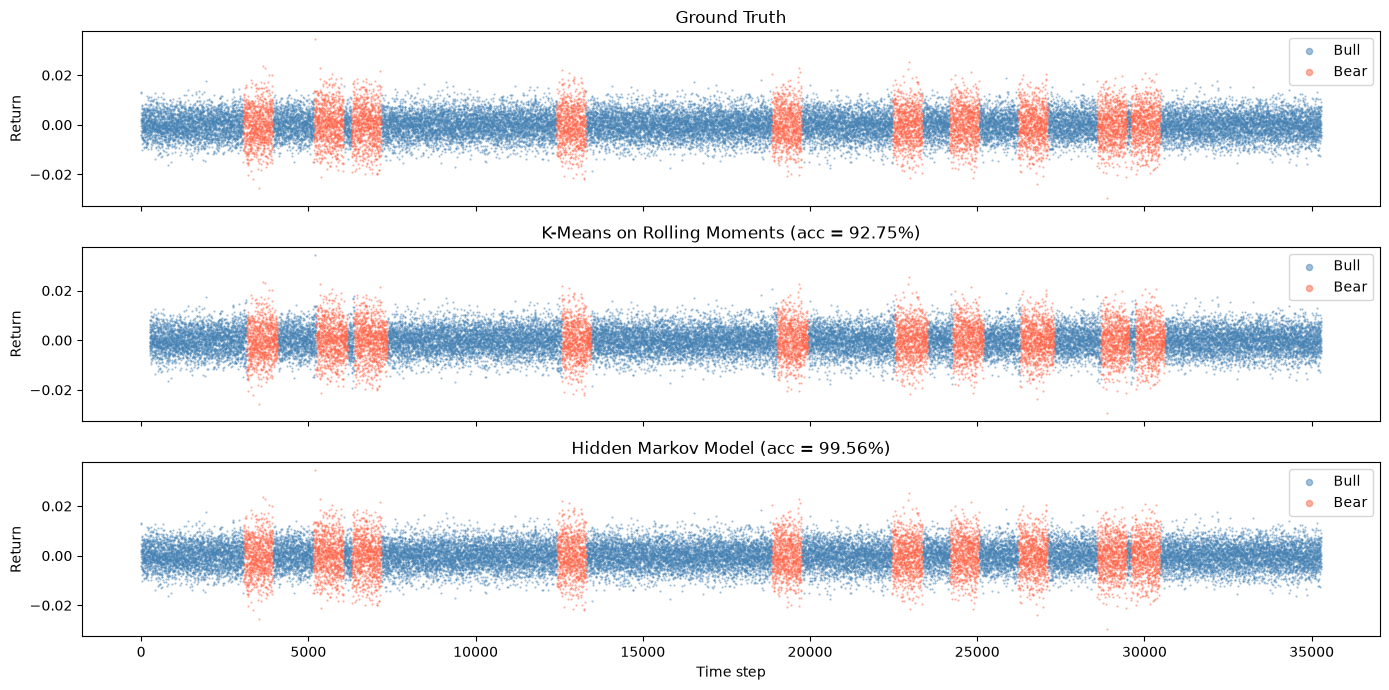

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

t_km = np.arange(window-1, len(returns_1d))  # time indices aligned with k-means output
t_full = np.arange(len(returns_1d))

# Flip labels if needed so colours match ground truth
if (km_labels != true_aligned).mean() > 0.5:
    km_labels = 1 - km_labels
if (hmm_labels != true_labels_1d).mean() > 0.5:
    hmm_labels = 1 - hmm_labels

colors = {0: 'steelblue', 1: 'tomato'}
regime_names = {0: 'Bull', 1: 'Bear'}

# --- Ground truth ---
for r in [0, 1]:
    mask = true_labels_1d == r
    axes[0].scatter(t_full[mask], returns_1d[mask], s=0.3, c=colors[r], alpha=0.5, label=regime_names[r])
axes[0].set_ylabel('Return')
axes[0].set_title('Ground Truth')
axes[0].legend(loc='upper right', markerscale=8)

# --- K-Means predictions ---
for r in [0, 1]:
    mask = km_labels == r
    axes[1].scatter(t_km[mask], returns_1d[window-1:][mask], s=0.3, c=colors[r], alpha=0.5, label=regime_names[r])
axes[1].set_ylabel('Return')
axes[1].set_title(f'K-Means on Rolling Moments (acc = {acc_km:.2%})')
axes[1].legend(loc='upper right', markerscale=8)

# --- HMM predictions ---
for r in [0, 1]:
    mask = hmm_labels == r
    axes[2].scatter(t_full[mask], returns_1d[mask], s=0.3, c=colors[r], alpha=0.5, label=regime_names[r])
axes[2].set_ylabel('Return')
axes[2].set_title(f'Hidden Markov Model (acc = {acc_hmm:.2%})')
axes[2].legend(loc='upper right', markerscale=8)
axes[2].set_xlabel('Time step')

plt.tight_layout()
plt.show()

Now for the main show.

The **Wasserstein distance**  quantifies the cost of optimally transporting mass from one probability distribution to another.


Let $(\mathcal{X}, d)$ be a metric space and let $\mu, \nu \in \mathbb{P}_p(\mathcal{X})$ be probability measures with finite $p$-th moment.

The $p$-Wasserstein distance is then defined (for $p \ge 1$) as:
$$W_p(\mu, \nu) = \left( \inf_{\gamma \in \Gamma(\mu,\nu)} \int_{\mathcal{X} \times \mathcal{X}} d(x,y)^p \, \mathrm{d}\gamma(x,y) \right)^{1/p}$$
where $\Gamma(\mu,\nu)$ is the set of all *couplings* (joint distributions) $\gamma$ on $\mathcal{X} \times \mathcal{X}$ with marginals $\mu$ and $\nu$.


Two key properties of $W_p$ is:
- It is a true metric on $\mathbb{P}_p(\mathcal{X})$ (non-negative, symmetric, satisfies the triangle inequality, and $W_p(\mu,\nu)=0 \iff \mu=\nu$).
- Convergence in $W_p$ is equivalent to weak convergence plus convergence of $p$-th moments.

When $\mathcal{X} = \mathbb{R}$ and $p=1$, the distance simplifies to:
$$W_1(\mu, \nu) = \int_0^1 |F_\mu^{-1}(q) - F_\nu^{-1}(q)|\, \mathrm{d}q$$
where $F^{-1}$ denotes the quantile function. For general $p$:
$$W_p^p(\mu, \nu) = \int_0^1 |F_\mu^{-1}(q) - F_\nu^{-1}(q)|^p\, \mathrm{d}q$$
This makes 1D Wasserstein computations very cheap, just sort the samples.

For empirical measures $\mu = \frac{1}{n}\sum_{i=1}^n \delta_{x_i}$ and $\nu = \frac{1}{n}\sum_{j=1}^n \delta_{y_j}$ with equal mass, $W_p^p$ reduces to a minimum-cost matching. In 1D this is solved by sorting both samples and pairing them in order:
$$W_p^p(\mu, \nu) = \frac{1}{n}\sum_{i=1}^n |x_{(i)} - y_{(i)}|^p.$$

In order to do k-means with the Wasserstein distance, we need to also consider how a cluster centroid is defined. For this we can use so called Wasserstein barycentre. The (1D) **Wasserstein barycentre** of a family $\{\mu_m\}$ of distributions is given element-wise (after sorting) by:
- $p=1$: $\bar{\mu}_j = \text{Median}(\mu_{1,j}^*, \ldots, \mu_{M,j}^*)$
- $p=2$: $\bar{\mu}_j = \text{Mean}(\mu_{1,j}^*, \ldots, \mu_{M,j}^*)$



And for a little consistency we also define lifting transformations which is how we get the empirical distributions which we will create clusters with.

Given a time series $S = (s_1, \ldots, s_N)$, we compute log-returns:
$$r_i = \log(s_{i+1}) - \log(s_i)$$

We then apply a **sliding window (lifting) transformation** $\ell$ with window size $h_1$ and offset $h_2$:
$$\ell^m(\mathbf{x}) = (x_{1+h_2(m-1)}, \ldots, x_{1+h_2(m-1)+h_1-1}) \quad \text{for } m=1,\ldots,M$$

where $M = \lfloor (N - (h_1 - h_2)) / h_2 \rfloor$.

Each window defines an **empirical distribution** $\mu_m = \frac{1}{h_1}\sum_i \delta_{\ell^m(\mathbf{x})_i}$.

The family $\mathcal{K} = \{\mu_m\}_{1 \leq m \leq M}$ is what we cluster.

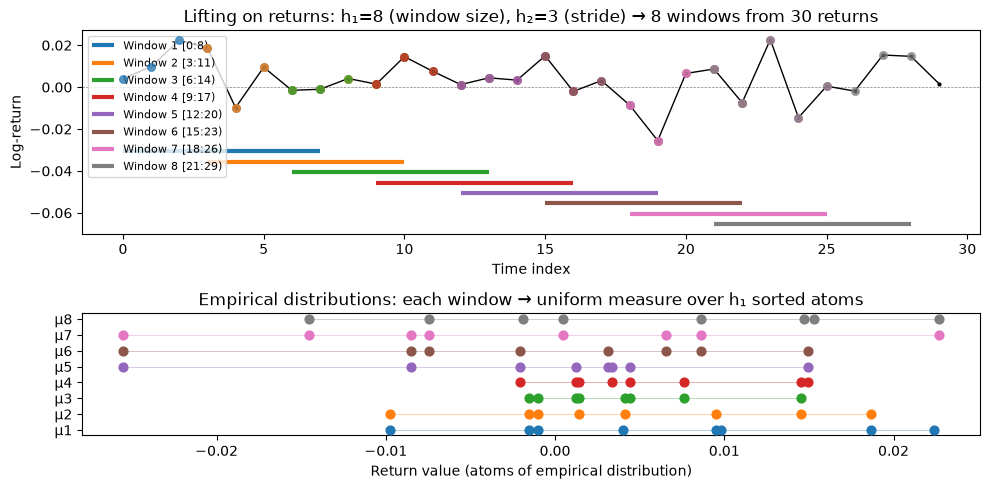

Returns length: 30, Windows extracted: 8, Each window: 8 atoms


In [5]:
def lift(returns, h1, h2):
    """Sliding window lifting transformation.
    
    Args:
        returns: array of shape (N,) or (N, d)
        h1: window size
        h2: window offset (stride)
    
    Returns:
        array of shape (M, h1) or (M, h1, d) — the empirical distributions
    """
    N = len(returns)
    M = (N - (h1 - h2)) // h2
    if returns.ndim == 1:
        return np.array([returns[h2*m : h2*m + h1] for m in range(M)])
    else:
        return np.array([returns[h2*m : h2*m + h1, :] for m in range(M)])

# Demo: visualize the lifting on a short series
np.random.seed(0)
demo_prices = np.exp(np.cumsum(np.random.randn(31) * 0.01))  # 31 prices -> 30 returns
demo_returns = np.diff(np.log(demo_prices))  # log-returns
h1, h2 = 8, 3
windows = lift(demo_returns, h1, h2)
n_show = len(windows)
colors = plt.cm.tab10(np.arange(n_show))

fig, axes = plt.subplots(2, 1, figsize=(10, 5), gridspec_kw={'height_ratios': [2, 1.2]})

# Top: log-returns with colored brackets showing each window's full extent
axes[0].plot(np.arange(len(demo_returns)), demo_returns, 'k.-', lw=1, markersize=4, zorder=5)
axes[0].axhline(0, color='gray', lw=0.5, ls='--')
ymin = demo_returns.min()
for m in range(n_show):
    start = h2 * m
    end = start + h1 - 1
    y_offset = ymin - 0.005 * (m + 1)
    axes[0].plot([start, end], [y_offset, y_offset], color=colors[m], lw=3, solid_capstyle='butt',
                label=f'Window {m+1} [{start}:{start+h1})')
    axes[0].scatter(np.arange(start, start + h1), demo_returns[start:start+h1],
                     s=30, zorder=6, alpha=0.7)
axes[0].set_xlabel('Time index')
axes[0].set_ylabel('Log-return')
axes[0].set_title(f'Lifting on returns: h\u2081={h1} (window size), h\u2082={h2} (stride) \u2192 {len(windows)} windows from {len(demo_returns)} returns')
axes[0].legend(fontsize=8, loc='upper left')

# Bottom: each window as an empirical distribution (sorted atoms on the real line)
for m in range(n_show):
    sorted_atoms = np.sort(windows[m])
    axes[1].scatter(sorted_atoms, np.full(h1, m), color=colors[m], s=40, 
                    zorder=5, label=f'\u03bc\u2098 (Window {m+1})')
    axes[1].hlines(m, sorted_atoms.min(), sorted_atoms.max(), color=colors[m], lw=0.5, alpha=0.5)
axes[1].set_xlabel('Return value (atoms of empirical distribution)')
axes[1].set_yticks(range(n_show))
axes[1].set_yticklabels([f'\u03bc{m+1}' for m in range(n_show)])
axes[1].set_title('Empirical distributions: each window \u2192 uniform measure over h\u2081 sorted atoms')

plt.tight_layout()
plt.show()

print(f"Returns length: {len(demo_returns)}, Windows extracted: {len(windows)}, Each window: {h1} atoms")


The 1D Wasserstein k-means algorithm then looks like (we will use p=1):

1. Compute log-returns, apply lifting → family of empirical distributions $\mathcal{K}$
2. Initialize $k$ centroids by sampling from $\mathcal{K}$
3. Iterate until convergence:
   - Assign each $\mu_j$ to nearest centroid (using $\mathcal{W}_p$)
   - Update centroids as Wasserstein barycentres of their clusters
4. Apply majority voting to assign each time point a single label

Wasserstein k-means accuracy: 98.25%


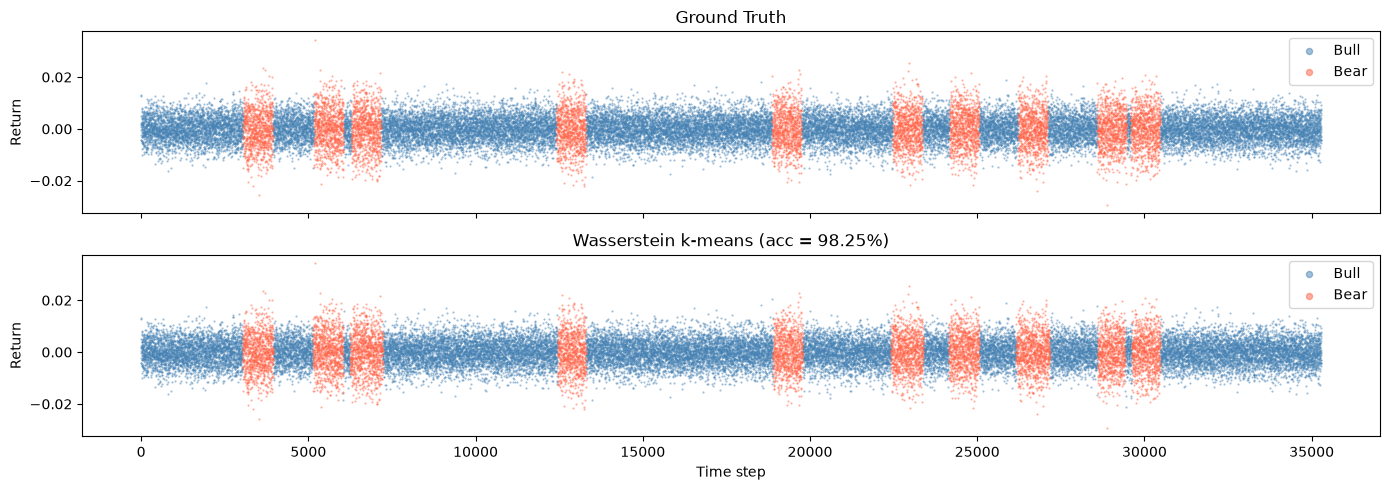

In [6]:
# --- 1D Wasserstein k-means ---
def wasserstein_kmeans_1d(returns, h1, h2, K=2, p=1, max_iter=100, seed=42):
    """1D Wasserstein k-means clustering.
    
    1. Lift returns into empirical distributions
    2. Initialize centroids by sampling from lifted windows
    3. Iterate: assign windows to nearest centroid (W_p), update centroids as barycentres
    4. Return per-window cluster labels
    """
    rng = np.random.default_rng(seed)
    
    # Step 1: Lift
    windows = lift(returns, h1, h2)  # (M, h1)
    M = len(windows)
    
    # Sort each window (empirical quantile representation)
    sorted_windows = np.sort(windows, axis=1)  # (M, h1)
    
    # Step 2: Initialize centroids by picking K random windows
    init_idx = rng.choice(M, size=K, replace=False)
    centroids = sorted_windows[init_idx].copy()  # (K, h1)
    
    labels = np.zeros(M, dtype=int)
    
    for iteration in range(max_iter):
        # Step 3a: Assign each window to nearest centroid using W_p
        # W_p^p = (1/h1) * sum |sorted_window_i - centroid_i|^p
        dists = np.zeros((M, K))
        for k in range(K):
            dists[:, k] = np.mean(np.abs(sorted_windows - centroids[k]) ** p, axis=1)
        
        new_labels = np.argmin(dists, axis=1)
        
        # Check convergence
        if np.array_equal(new_labels, labels) and iteration > 0:
            break
        labels = new_labels
        
        # Step 3b: Update centroids as Wasserstein barycentres
        for k in range(K):
            members = sorted_windows[labels == k]
            if len(members) == 0:
                continue
            if p == 1:
                centroids[k] = np.median(members, axis=0)
            else:
                centroids[k] = np.mean(members, axis=0)
    
    return labels, centroids, sorted_windows

# Parameters
h1_wk = 252  # window size (same as rolling moments window for fair comparison)
h2_wk = 1    # stride of 1 for maximum resolution

wk_labels, wk_centroids, wk_sorted = wasserstein_kmeans_1d(returns_1d, h1_wk, h2_wk, K=2, p=1)

# Map window labels back to point labels via majority voting
M_wk = len(wk_labels)
point_labels_wk = np.zeros(len(returns_1d), dtype=int)
point_counts = np.zeros(len(returns_1d), dtype=int)

for m in range(M_wk):
    start = h2_wk * m
    end = start + h1_wk
    point_labels_wk[start:end] += wk_labels[m]
    point_counts[start:end] += 1

# Majority vote: if more than half of overlapping windows say cluster 1, assign 1
point_counts = np.maximum(point_counts, 1)
point_labels_wk = (point_labels_wk / point_counts > 0.5).astype(int)

# Accuracy (handle label flipping)
acc_wk = max((point_labels_wk == true_labels_1d).mean(),
             (point_labels_wk != true_labels_1d).mean())
print(f"Wasserstein k-means accuracy: {acc_wk:.2%}")

# Flip labels for plotting if needed
if (point_labels_wk != true_labels_1d).mean() > 0.5:
    point_labels_wk = 1 - point_labels_wk

# --- Plot Wasserstein k-means result ---
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
t_full = np.arange(len(returns_1d))

for r in [0, 1]:
    mask = true_labels_1d == r
    axes[0].scatter(t_full[mask], returns_1d[mask], s=0.3, c={0:"steelblue",1:"tomato"}[r], alpha=0.5, label={0:"Bull",1:"Bear"}[r])
axes[0].set_ylabel("Return"); axes[0].set_title("Ground Truth")
axes[0].legend(loc="upper right", markerscale=8)

for r in [0, 1]:
    mask = point_labels_wk == r
    axes[1].scatter(t_full[mask], returns_1d[mask], s=0.3, c={0:"steelblue",1:"tomato"}[r], alpha=0.5, label={0:"Bull",1:"Bear"}[r])
axes[1].set_ylabel("Return"); axes[1].set_title(f"Wasserstein k-means (acc = {acc_wk:.2%})")
axes[1].set_xlabel("Time step"); axes[1].legend(loc="upper right", markerscale=8)

plt.tight_layout(); plt.show()


Best non-Wasserstein: HMM (accuracy: 99.56%)
Wasserstein k-means accuracy: 98.25%



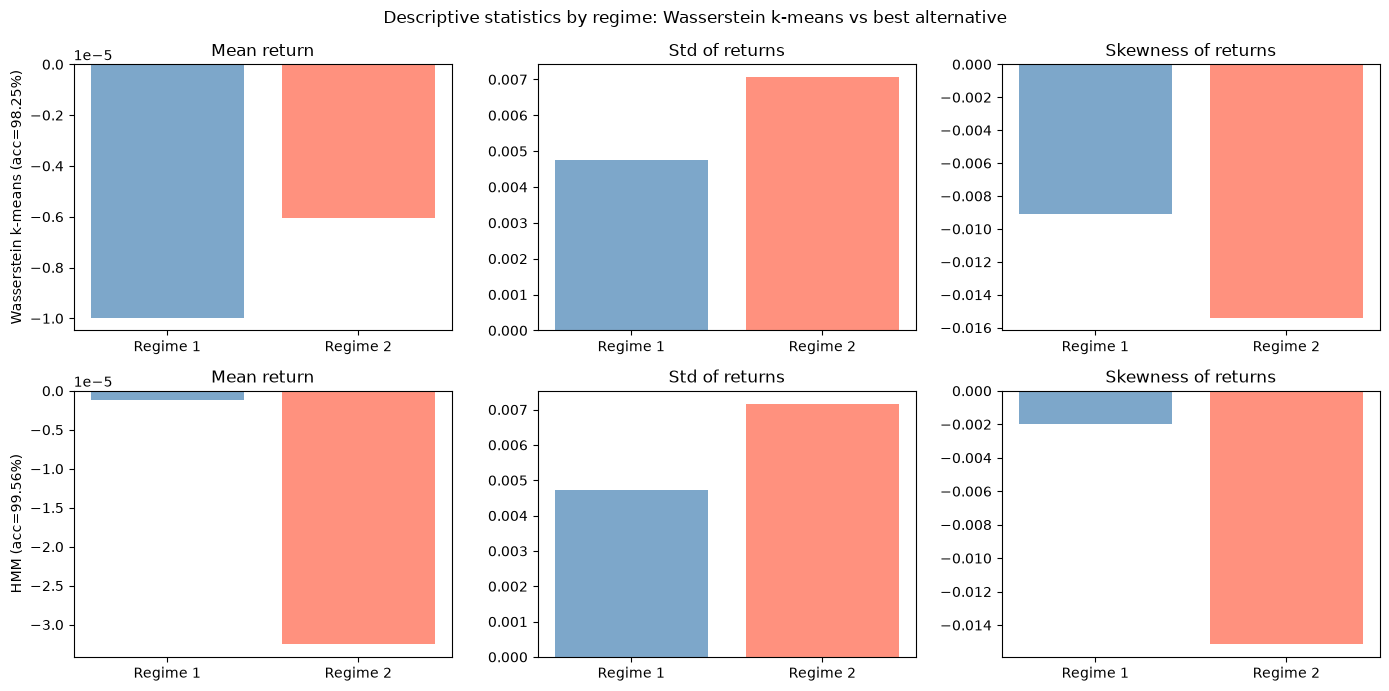

In [7]:
# --- Comparison: Best non-Wasserstein vs Wasserstein ---
best_non_wk_name = "K-Means (moments)" if acc_km >= acc_hmm else "HMM"
best_non_wk_acc = max(acc_km, acc_hmm)
best_non_wk_labels = km_labels if acc_km >= acc_hmm else hmm_labels
# Align to full length for statistics
if acc_km >= acc_hmm:
    # km_labels is shorter (aligned to window-1:)
    best_non_wk_point_labels = np.full(len(returns_1d), -1, dtype=int)
    best_non_wk_point_labels[window-1:] = km_labels
    stat_mask = best_non_wk_point_labels >= 0
else:
    best_non_wk_point_labels = hmm_labels
    stat_mask = np.ones(len(returns_1d), dtype=bool)

# Ensure labels are flipped correctly for stats
if acc_km >= acc_hmm:
    if (km_labels != true_aligned).mean() > 0.5:
        best_non_wk_point_labels[window-1:] = 1 - km_labels
else:
    if (hmm_labels != true_labels_1d).mean() > 0.5:
        best_non_wk_point_labels = 1 - hmm_labels

print(f"Best non-Wasserstein: {best_non_wk_name} (accuracy: {best_non_wk_acc:.2%})")
print(f"Wasserstein k-means accuracy: {acc_wk:.2%}")
print()

# --- Descriptive statistics per regime for both methods ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

K = 2
regime_colors = ["steelblue", "tomato"]

for row, (method_name, method_labels, method_mask) in enumerate([
    (f"Wasserstein k-means (acc={acc_wk:.2%})", point_labels_wk, np.ones(len(returns_1d), dtype=bool)),
    (f"{best_non_wk_name} (acc={best_non_wk_acc:.2%})", best_non_wk_point_labels, stat_mask),
]):
    raw = returns_1d[method_mask]
    labs = method_labels[method_mask]
    
    mean_ret, std_ret, skew_ret = [], [], []
    for k in range(K):
        m = labs == k
        r = raw[m]
        mean_ret.append(r.mean())
        std_ret.append(r.std())
        skew_ret.append(((r - r.mean())**3).mean() / r.std()**3 if r.std() > 0 else 0)

    x = np.arange(K)
    
    axes[row, 0].bar(x, mean_ret, color=regime_colors, alpha=0.7)
    axes[row, 0].set_xticks(x); axes[row, 0].set_xticklabels([f"Regime {k+1}" for k in range(K)])
    axes[row, 0].set_title("Mean return"); axes[row, 0].axhline(0, color="k", lw=0.5)
    
    axes[row, 1].bar(x, std_ret, color=regime_colors, alpha=0.7)
    axes[row, 1].set_xticks(x); axes[row, 1].set_xticklabels([f"Regime {k+1}" for k in range(K)])
    axes[row, 1].set_title("Std of returns")
    
    axes[row, 2].bar(x, skew_ret, color=regime_colors, alpha=0.7)
    axes[row, 2].set_xticks(x); axes[row, 2].set_xticklabels([f"Regime {k+1}" for k in range(K)])
    axes[row, 2].set_title("Skewness of returns"); axes[row, 2].axhline(0, color="k", lw=0.5)
    
    axes[row, 0].set_ylabel(method_name)

plt.suptitle("Descriptive statistics by regime: Wasserstein k-means vs best alternative", fontsize=12)
plt.tight_layout(); plt.show()


Now more dimensions. For that we use the sliced Wasserstein distance, by approximating the full Wasserstein distance by averaging 1D distances over projections:

$$\overline{\mathcal{W}}_p(\mu, \nu) \approx \frac{1}{L}\sum_{l=1}^L \mathcal{W}_p(\mu'(\theta^l), \nu'(\theta^l))$$

where $\mu'(\theta) = \frac{1}{N}\sum_i \delta_{\langle x_i, \theta \rangle}$ is the projected measure along direction $\theta \in \mathbb{S}^{d-1}$.

The process thus looks like:

1. Compute returns, apply lifting → family $\mathcal{K} = \{\mu_j\}$ of $d$-dimensional distributions
2. Choose projection directions; compute & sort projected distributions $\mu_j'(\theta^l)$ for all $j, l$
3. Initialize $K$ centroids (by their projections)
4. Iterate:
   - Assign each $\mu_j$ to nearest centroid using $\overline{\mathcal{W}}_p$
   - Update each centroid projection $\bar{\mu}_k'(\theta^l)$ as the 1D Wasserstein barycentre of its cluster members' projections
5. Majority voting for final labels

**Key advantage:** Projections need only be computed and sorted once. The barycentre is computed per-projection in 1D — no need for the expensive multidimensional barycentre.

### Synthetic 2D Data

- **Type A:** Bull ($\rho=+0.5$) vs Bear ($\rho=+0.5$) — same correlation, different marginals
- **Type B:** Bull ($\rho=+0.5$) vs Bull ($\rho=-0.5$) — same marginals, different correlation

In [8]:
def generate_gbm_2d(n_years=20, obs_per_day=7, days_per_year=252,
                    theta_bull=(0.02, 0.2), theta_bear=(-0.02, 0.3),
                    rho_regimes=(0.5, 0.5), n_bear_periods=10,
                    bear_length_years=0.5, seed=42):
    """Generate 2D correlated GBM with two regimes."""
    rng = np.random.default_rng(seed)
    N = n_years * days_per_year * obs_per_day
    dt = 1.0 / (days_per_year * obs_per_day)
    bear_len = int(bear_length_years * days_per_year * obs_per_day)
    
    labels = np.zeros(N, dtype=int)
    starts = []
    for _ in range(n_bear_periods):
        for _attempt in range(1000):
            s = rng.integers(0, N - bear_len)
            if all(abs(s - prev) >= bear_len for prev in starts):
                starts.append(s)
                break
        labels[s:s+bear_len] = 1
    
    # Generate correlated 2D returns
    returns = np.zeros((N, 2))
    for regime in [0, 1]:
        mask = labels == regime
        n_pts = mask.sum()
        theta = theta_bull if regime == 0 else theta_bear
        mu_val, sig_val = theta
        rho = rho_regimes[regime]
        
        # Independent normals
        z1 = rng.normal(0, 1, n_pts)
        z2 = rng.normal(0, 1, n_pts)
        # Correlate
        r1 = (mu_val - sig_val**2/2)*dt + sig_val*np.sqrt(dt)*z1
        r2 = (mu_val - sig_val**2/2)*dt + sig_val*np.sqrt(dt)*(rho*z1 + np.sqrt(1-rho**2)*z2)
        returns[mask, 0] = r1
        returns[mask, 1] = r2
    
    prices = np.exp(np.cumsum(returns, axis=0))
    return prices, returns, labels


In [9]:
def generate_projections(d, L):
    """Generate L evenly-spaced unit vectors on S^(d-1).
    
    For d=2: uniform angles on the circle.
    For d=3: Fibonacci sphere approximation.
    """
    if d == 2:
        angles = np.linspace(0, np.pi, L, endpoint=False)
        return np.column_stack([np.cos(angles), np.sin(angles)])
    elif d == 3:
        # Fibonacci sphere
        indices = np.arange(L)
        phi = np.arccos(1 - 2 * (indices + 0.5) / L)
        theta = np.pi * (1 + 5**0.5) * indices
        return np.column_stack([np.sin(phi)*np.cos(theta), 
                                np.sin(phi)*np.sin(theta), np.cos(phi)])
    else:
        # Random projections for d>3
        vecs = np.random.randn(L, d)
        return vecs / np.linalg.norm(vecs, axis=1, keepdims=True)
def wasserstein_1d(mu, nu, p=1):
    """1D p-Wasserstein distance between two empirical distributions."""
    return np.mean(np.abs(np.sort(mu) - np.sort(nu))**p)**(1/p)

def sliced_wasserstein(mu, nu, projections, p=1):
    """Sliced Wasserstein distance between two d-dimensional empirical distributions.
    
    Args:
        mu: array (N, d) — atoms of first distribution
        nu: array (N, d) — atoms of second distribution
        projections: array (L, d) — unit projection vectors
    """
    total = 0.0
    for theta in projections:
        mu_proj = mu @ theta
        nu_proj = nu @ theta
        total += wasserstein_1d(mu_proj, nu_proj, p)
    return total / len(projections)

def swkmeans(distributions_nd, K, L=9, max_iter=100, tol=1e-6, seed=None):
    """Sliced Wasserstein k-means for multidimensional empirical distributions.
    
    Args:
        distributions_nd: array (M, h1, d) — M empirical distributions, each with h1 atoms in R^d
        K: number of clusters
        L: number of projection directions
        max_iter: maximum iterations
        tol: convergence tolerance
        seed: random seed
    
    Returns:
        labels: array (M,) — cluster assignments
        centroid_projections: dict with projected centroids
    """
    rng = np.random.default_rng(seed)
    M, h1, d = distributions_nd.shape
    projections = generate_projections(d, L)
    
    # Pre-compute and sort projected distributions: shape (L, M, h1)
    projected = np.zeros((L, M, h1))
    for l, theta in enumerate(projections):
        for m in range(M):
            projected[l, m] = np.sort(distributions_nd[m] @ theta)
    
    # Initialize centroids by sampling K distributions
    idx = rng.choice(M, K, replace=False)
    # Centroid projections: shape (L, K, h1)
    centroid_proj = projected[:, idx, :].copy()  # (L, K, h1)
    centroid_proj = np.swapaxes(centroid_proj, 0, 1)  # (K, L, h1)
    
    labels = np.zeros(M, dtype=int)
    for _ in range(max_iter):
        # Assign each distribution to nearest centroid via sliced Wasserstein
        # Distance matrix (M, K)
        dist_matrix = np.zeros((M, K))
        for k in range(K):
            for l in range(L):
                dist_matrix[:, k] += np.mean(np.abs(projected[l] - centroid_proj[k, l]), axis=1)
        dist_matrix /= L
        new_labels = np.argmin(dist_matrix, axis=1)
        
        # Update centroids
        new_centroid_proj = np.empty_like(centroid_proj)
        for k in range(K):
            members = (new_labels == k)
            if members.sum() == 0:
                new_centroid_proj[k] = centroid_proj[k]
            else:
                for l in range(L):
                    new_centroid_proj[k, l] = np.median(projected[l, members], axis=0)
        
        # Convergence check
        shift = 0.0
        for k in range(K):
            for l in range(L):
                shift += np.mean(np.abs(new_centroid_proj[k, l] - centroid_proj[k, l]))
        
        centroid_proj = new_centroid_proj
        labels = new_labels
        if shift < tol:
            break
    
    return labels, centroid_proj


def centroid_separation(centroid_proj):
    """Mean pairwise sliced Wasserstein distance between centroids."""
    K = centroid_proj.shape[0]
    L = centroid_proj.shape[1]
    total = 0.0
    count = 0
    for i in range(K):
        for j in range(i+1, K):
            for l in range(L):
                total += np.mean(np.abs(centroid_proj[i, l] - centroid_proj[j, l]))
            count += 1
    return total / (count * L) if count > 0 else 0.0


Type A — Lifted: 5036 windows of shape (35, 2)
Type A accuracy: 99.2%


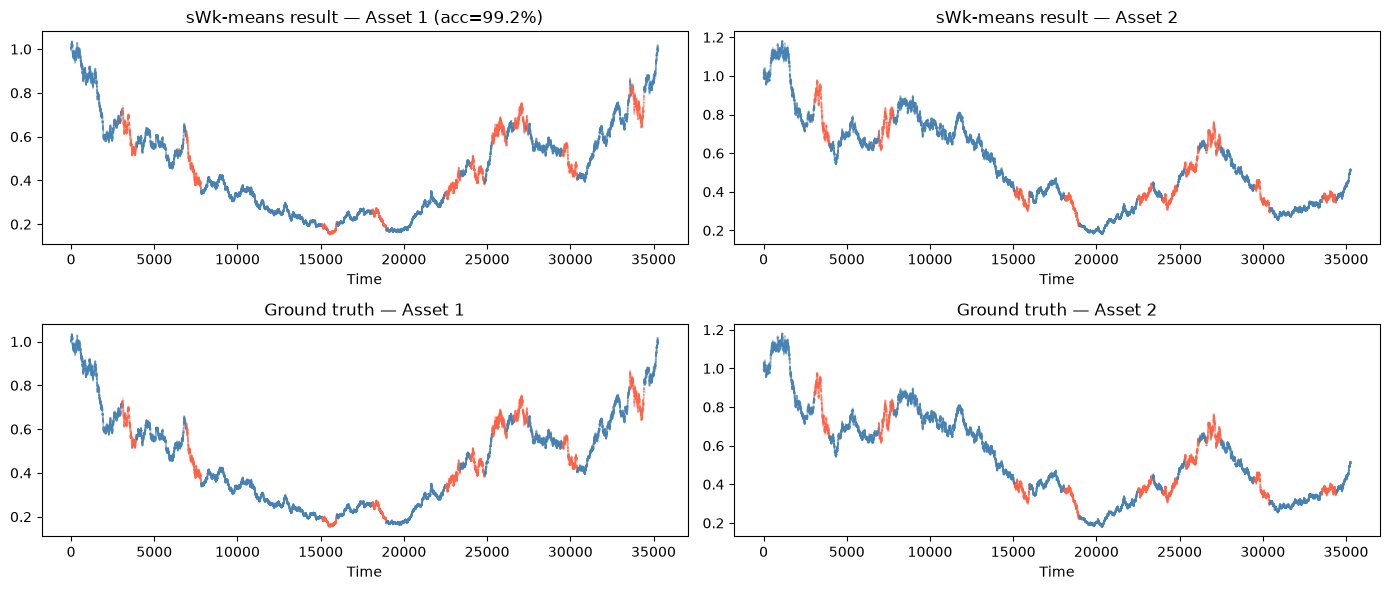

In [10]:
# Generate Type A data (bull vs bear, same correlation)
prices_2d_a, returns_2d_a, labels_2d_a = generate_gbm_2d(
    rho_regimes=(0.5, 0.5), seed=42)

# Lift and cluster
h1, h2, L = 35, 7, 9
windows_2d_a = lift(returns_2d_a, h1, h2)
print(f"Type A — Lifted: {windows_2d_a.shape[0]} windows of shape ({h1}, 2)")

# Multiple runs, select by centroid separation
best_sep_a, best_labels_a = -1, None
for run in range(30):
    seq_lab, cproj = swkmeans(windows_2d_a, K=2, L=L, seed=run)
    sep = centroid_separation(cproj)
    if sep > best_sep_a:
        best_sep_a = sep
        best_labels_a = seq_lab
        
def majority_vote(seq_labels, N, h1, h2):
    """Assign each time point a label via majority voting over overlapping windows."""
    votes = np.zeros((N, seq_labels.max() + 1))
    M = len(seq_labels)
    for m in range(M):
        start = h2 * m
        votes[start:start+h1, seq_labels[m]] += 1
    return np.argmax(votes, axis=1)


def total_accuracy(predicted, true_labels, K=2):
    """Compute accuracy, handling label permutations."""
    from itertools import permutations
    best = 0.0
    for perm in permutations(range(K)):
        remapped = np.array([perm[l] for l in predicted])
        best = max(best, np.mean(remapped == true_labels))
    return best
point_labels_a = majority_vote(best_labels_a, len(returns_2d_a), h1, h2)
acc_a = total_accuracy(point_labels_a, labels_2d_a, K=2)
print(f"Type A accuracy: {acc_a:.1%}")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
t2 = np.arange(len(prices_2d_a))
colors_pred = np.where(point_labels_a == point_labels_a[0], 'steelblue', 'tomato')
colors_true = np.where(labels_2d_a == 0, 'steelblue', 'tomato')

axes[0,0].scatter(t2, prices_2d_a[:,0], s=0.1, c=colors_pred, alpha=0.4)
axes[0,0].set_title(f'sWk-means result — Asset 1 (acc={acc_a:.1%})')
axes[0,1].scatter(t2, prices_2d_a[:,1], s=0.1, c=colors_pred, alpha=0.4)
axes[0,1].set_title('sWk-means result — Asset 2')
axes[1,0].scatter(t2, prices_2d_a[:,0], s=0.1, c=colors_true, alpha=0.4)
axes[1,0].set_title('Ground truth — Asset 1')
axes[1,1].scatter(t2, prices_2d_a[:,1], s=0.1, c=colors_true, alpha=0.4)
axes[1,1].set_title('Ground truth — Asset 2')
for ax in axes.flat:
    ax.set_xlabel('Time')
plt.tight_layout(); plt.show()


On real FX data now, comparing with a multidimensional HMM.

In [11]:
import yfinance as yf

# Fetch daily FX data
print("Fetching FX data from yfinance...")
usdjpy = yf.download("USDJPY=X", start="2007-04-30", end="2023-08-08", progress=False)
gbpusd = yf.download("GBPUSD=X", start="2007-04-30", end="2023-08-08", progress=False)

# Align dates and compute log returns
usdjpy_close = usdjpy['Close'].dropna()
gbpusd_close = gbpusd['Close'].dropna()
common_idx = usdjpy_close.index.intersection(gbpusd_close.index)
usdjpy_close = usdjpy_close.loc[common_idx]
gbpusd_close = gbpusd_close.loc[common_idx]

returns_usd = np.diff(np.log(usdjpy_close.values.flatten()))
returns_gbp = np.diff(np.log(gbpusd_close.values.flatten()))
returns_fx = np.column_stack([returns_usd, returns_gbp])

# Standardize
returns_fx = (returns_fx - returns_fx.mean(axis=0)) / returns_fx.std(axis=0)
dates = common_idx[1:]
print(f"FX data: {len(returns_fx)} daily observations, {dates[0].date()} to {dates[-1].date()}")


Fetching FX data from yfinance...
FX data: 4214 daily observations, 2007-05-01 to 2023-08-07


Lifted: 347 windows of shape (60, 2)
Regime distribution: Regime 1: 61.8%, Regime 2: 2.3%, Regime 3: 35.9%


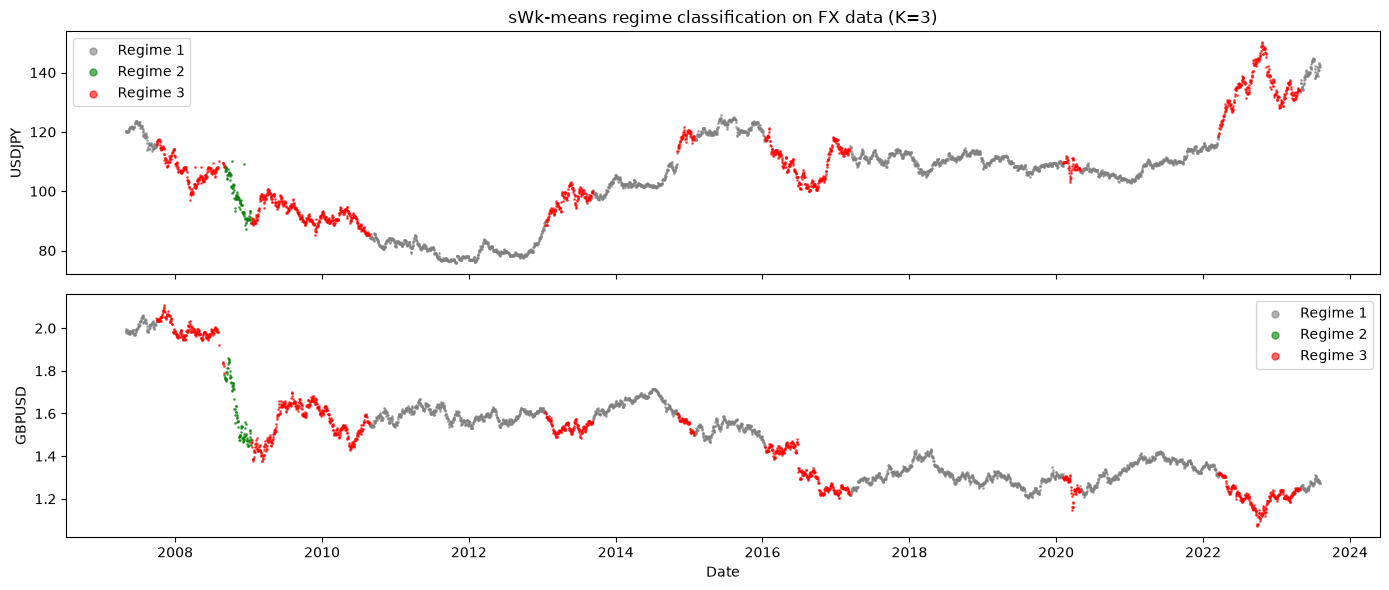

In [15]:
# Apply sWk-means with K=3
h1_fx, h2_fx, L_fx, K_fx = 60, 12, 16, 3
windows_fx = lift(returns_fx, h1_fx, h2_fx)
print(f"Lifted: {windows_fx.shape[0]} windows of shape ({h1_fx}, 2)")

best_sep_fx, best_labels_fx = -1, None
for run in range(100):
    seq_lab, cproj = swkmeans(windows_fx, K=K_fx, L=L_fx, seed=run)
    sep = centroid_separation(cproj)
    if sep > best_sep_fx:
        best_sep_fx = sep
        best_labels_fx = seq_lab
        best_cproj_fx = cproj

point_labels_fx = majority_vote(best_labels_fx, len(returns_fx), h1_fx, h2_fx)
print(f"Regime distribution: " + 
      ", ".join(f"Regime {k+1}: {(point_labels_fx==k).mean():.1%}" for k in range(K_fx)))

# Visualize regimes on time series
regime_colors = ['gray', 'green', 'red']
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

prices_usd = usdjpy_close.values.flatten()[1:]  # align with returns
prices_gbp = gbpusd_close.values.flatten()[1:]

for k in range(K_fx):
    mask = point_labels_fx == k
    axes[0].scatter(dates[mask], prices_usd[mask], s=1, c=regime_colors[k], alpha=0.6, label=f'Regime {k+1}')
    axes[1].scatter(dates[mask], prices_gbp[mask], s=1, c=regime_colors[k], alpha=0.6, label=f'Regime {k+1}')

axes[0].set_ylabel('USDJPY'); axes[0].set_title('sWk-means regime classification on FX data (K=3)')
axes[0].legend(markerscale=5)
axes[1].set_ylabel('GBPUSD'); axes[1].set_xlabel('Date')
axes[1].legend(markerscale=5)
plt.tight_layout(); plt.show()



HMM regime distribution: Regime 1: 44.9%, Regime 2: 52.5%, Regime 3: 2.6%


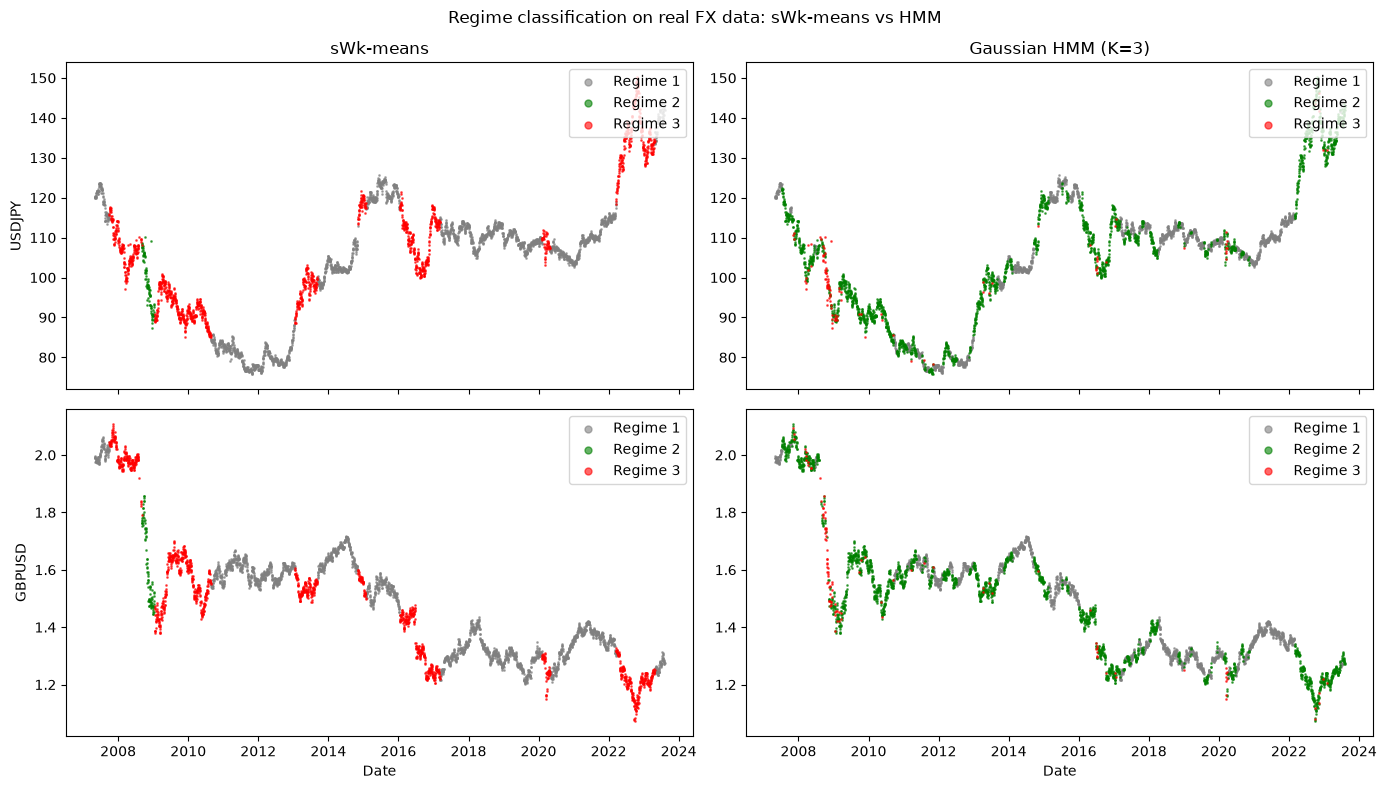

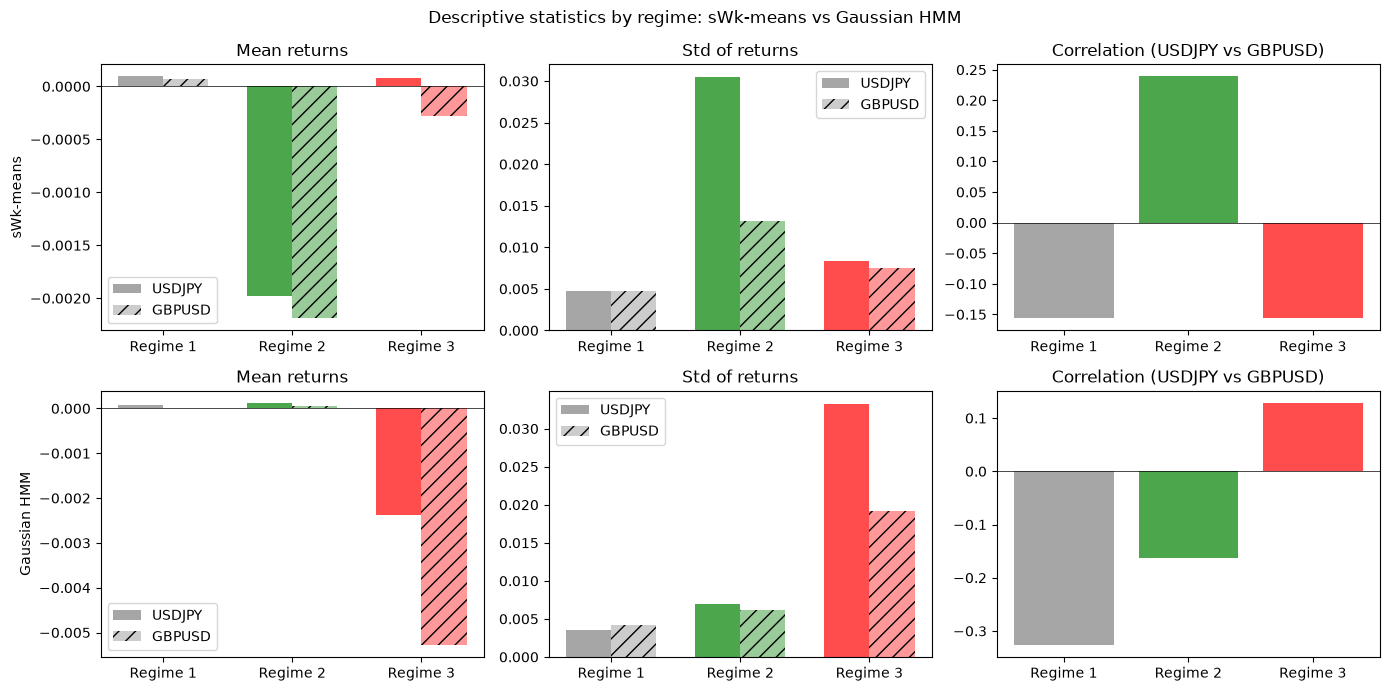

In [20]:
from hmmlearn.hmm import GaussianHMM

# --- Fit multidimensional Gaussian HMM ---
hmm_fx = GaussianHMM(n_components=K_fx, covariance_type='full', n_iter=300, random_state=42)
hmm_fx.fit(returns_fx)
hmm_labels_fx = hmm_fx.predict(returns_fx)
print(f"HMM regime distribution: " +
      ", ".join(f"Regime {k+1}: {(hmm_labels_fx==k).mean():.1%}" for k in range(K_fx)))

# --- Side-by-side time series plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
regime_colors = ['gray', 'green', 'red']
prices_usd = usdjpy_close.values.flatten()[1:]
prices_gbp = gbpusd_close.values.flatten()[1:]

for k in range(K_fx):
    mask_sw = point_labels_fx == k
    mask_hmm = hmm_labels_fx == k
    axes[0, 0].scatter(dates[mask_sw], prices_usd[mask_sw], s=1, c=regime_colors[k], alpha=0.6, label=f'Regime {k+1}')
    axes[1, 0].scatter(dates[mask_sw], prices_gbp[mask_sw], s=1, c=regime_colors[k], alpha=0.6, label=f'Regime {k+1}')
    axes[0, 1].scatter(dates[mask_hmm], prices_usd[mask_hmm], s=1, c=regime_colors[k], alpha=0.6, label=f'Regime {k+1}')
    axes[1, 1].scatter(dates[mask_hmm], prices_gbp[mask_hmm], s=1, c=regime_colors[k], alpha=0.6, label=f'Regime {k+1}')

axes[0, 0].set_ylabel('USDJPY'); axes[0, 0].set_title('sWk-means')
axes[1, 0].set_ylabel('GBPUSD'); axes[1, 0].set_xlabel('Date')
axes[0, 1].set_title('Gaussian HMM (K=3)')
axes[1, 1].set_xlabel('Date')
for ax in axes.flat:
    ax.legend(markerscale=5, loc='upper right')
plt.suptitle('Regime classification on real FX data: sWk-means vs HMM', fontsize=12)
plt.tight_layout(); plt.show()

# --- Descriptive statistics comparison ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
raw_returns_fx = np.column_stack([returns_usd, returns_gbp])

for row, (method_name, method_labels) in enumerate([
    ("sWk-means", point_labels_fx),
    ("Gaussian HMM", hmm_labels_fx),
]):
    mean_returns, std_returns, corr_returns = [], [], []
    for k in range(K_fx):
        mask = method_labels == k
        r = raw_returns_fx[mask]
        mean_returns.append([r[:, 0].mean(), r[:, 1].mean()])
        std_returns.append([r[:, 0].std(), r[:, 1].std()])
        corr_returns.append(np.corrcoef(r[:, 0], r[:, 1])[0, 1] if len(r) > 1 else 0)

    x = np.arange(K_fx)
    width = 0.35

    axes[row, 0].bar(x - width/2, [m[0] for m in mean_returns], width, color=regime_colors, alpha=0.7, label='USDJPY')
    axes[row, 0].bar(x + width/2, [m[1] for m in mean_returns], width, color=regime_colors, alpha=0.4,
                     hatch='//', label='GBPUSD')
    axes[row, 0].set_xticks(x); axes[row, 0].set_xticklabels([f'Regime {k+1}' for k in range(K_fx)])
    axes[row, 0].set_title('Mean returns'); axes[row, 0].legend(); axes[row, 0].axhline(0, color='k', lw=0.5)

    axes[row, 1].bar(x - width/2, [s[0] for s in std_returns], width, color=regime_colors, alpha=0.7, label='USDJPY')
    axes[row, 1].bar(x + width/2, [s[1] for s in std_returns], width, color=regime_colors, alpha=0.4,
                     hatch='//', label='GBPUSD')
    axes[row, 1].set_xticks(x); axes[row, 1].set_xticklabels([f'Regime {k+1}' for k in range(K_fx)])
    axes[row, 1].set_title('Std of returns'); axes[row, 1].legend()

    axes[row, 2].bar(x, corr_returns, color=regime_colors, alpha=0.7)
    axes[row, 2].set_xticks(x); axes[row, 2].set_xticklabels([f'Regime {k+1}' for k in range(K_fx)])
    axes[row, 2].set_title('Correlation (USDJPY vs GBPUSD)'); axes[row, 2].axhline(0, color='k', lw=0.5)

    axes[row, 0].set_ylabel(method_name)

plt.suptitle('Descriptive statistics by regime: sWk-means vs Gaussian HMM', fontsize=12)
plt.tight_layout(); plt.show()


They look quite alike (up to regime label permutations), and I actually think the sliced Wasserstein one looks more reasonable since its regimes are more "together" in general!